# Imports

In [1]:
import sys
from pathlib import Path
sys.path.append("..")

import argparse
import logging
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import umap.umap_ as umap

from styles.colors import get_colors
from src.core.data_utils import load_annotation, load_data
from src.core.logging_utils import setup_logging
from sklearn.metrics.pairwise import pairwise_distances

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

from sklearn.metrics import mutual_info_score, normalized_mutual_info_score

from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from scipy import stats
from statsmodels.stats.multitest import multipletests
from scipy.stats import mannwhitneyu

c:\Users\Love\miniconda3\envs\proteomicsEnv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load data

In [2]:
df = pd.read_csv("../data/processed/filtered_data.csv")

proteins = [c for c in df.columns if c.startswith("seq.")]
X = df[proteins].values
y = df["ards"].values

C:\Users\Love\AppData\Local\Temp\ipykernel_20680\1804087720.py:1: DtypeWarning: Columns (10818,10820) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/filtered_data.csv")


In [3]:
annot_df = pd.read_csv("../data/processed/somalogic_annotation.csv")
annot_df.head()

,PROBEID,SYMBOL,UNIPROT,ENTREZID,GENENAME
0,10000-28,CRYBB2,A0A0H3W5U0,1415.0,crystallin beta B2
1,10001-7,RAF1,A0A0S2Z559,5894.0,"Raf-1 proto-oncogene, serine/threonine kinase"
2,10003-15,ZNF41,P51814,7592.0,zinc finger protein 41
3,10006-25,ELK1,B2R7H4,2002.0,ETS transcription factor ELK1
4,10008-43,GUCA1A,B2R9P6,2978.0,guanylate cyclase activator 1A


## Data split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

## Functions

In [68]:
def run_kmeans_clustering(X, n_clusters=4):
    """Run KMeans clustering and return cluster labels."""
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(X)
    return cluster_labels, kmeans.cluster_centers_

def run_dbscan_clustering(X, eps=0.5, min_samples=10, metric="euclidean"):
    """Run DBSCAN clustering and return cluster labels."""
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric=metric)
    cluster_labels = dbscan.fit_predict(X)
    return cluster_labels

def plot_umap(X, cluster_labels, metric="cosine", random_state=42):
    """Plot UMAP embedding colored by cluster labels."""
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric=metric, random_state=random_state)
    embedding = reducer.fit_transform(X)

    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=cluster_labels+1, cmap='tab10', alpha=0.7)
    plt.title("UMAP Projection of Clusters")
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.grid(True, alpha=0.3)
    plt.legend(*scatter.legend_elements(), title="Clusters")
    plt.show()

def bar_plot_cluster_selection_probabilities(X, cluster_labels, proteins):
    """Bar plot of mean selection probabilities for each protein in each cluster."""
    unique_clusters = np.unique(cluster_labels)
    mean_selection_probs = {cluster: np.mean(X[cluster_labels == cluster], axis=0) for cluster in unique_clusters}

    x = np.arange(len(proteins))
    width = 1 / (len(unique_clusters)+1)

    plt.figure(figsize=(12, 6))
    for i, cluster in enumerate(unique_clusters):
        plt.bar(x + i*width - width/2 * len(unique_clusters), mean_selection_probs[cluster], width, label=f'Cluster {cluster+1 if cluster >= 0 else "Noise"}', alpha=0.7)
    
    plt.xlabel('Proteins')
    plt.ylabel('Mean Selection Probability')
    plt.title('Mean Selection Probability of Proteins in Each Cluster')
    plt.xticks(x, proteins, rotation=90)
    plt.legend()
    plt.tight_layout()
    plt.show()

def seq_to_probeid(name: str) -> str:
    s = str(name)
    s = re.sub(r"^seq\.", "", s)
    s = re.sub(r"^seq", "", s)
    # Replace first occurrence of digits.digits with digits-digits
    s = re.sub(r"([0-9]+)\.([0-9]+)", r"\1-\2", s)
    return s

# Protein selection

### Using t-tests

In [6]:
n_samples, n_features = X_train.shape
n_iterations = 100

p_vals_matrix_tt = np.zeros((n_iterations, n_features))

for b in range(n_iterations):
    if (b+1) % 10 == 0:
        print(f"Iteration {b+1}/{n_iterations}")
    X_sub, _, y_sub, _ = train_test_split(X_train, y_train, test_size=0.6, random_state=b)

    # t-tests
    _, p_vals = stats.ttest_ind(
        X_sub[y_sub == 1], 
        X_sub[y_sub == 0], 
        axis=0, 
        equal_var=False
    )

    # mutliple testing correction
    #_, p_vals_corrected, _, _ = multipletests(p_vals, method='fdr_bh')

    p_vals_matrix_tt[b] = p_vals

Iteration 10/100
Iteration 20/100
Iteration 30/100
Iteration 40/100
Iteration 50/100
Iteration 60/100
Iteration 70/100
Iteration 80/100
Iteration 90/100
Iteration 100/100


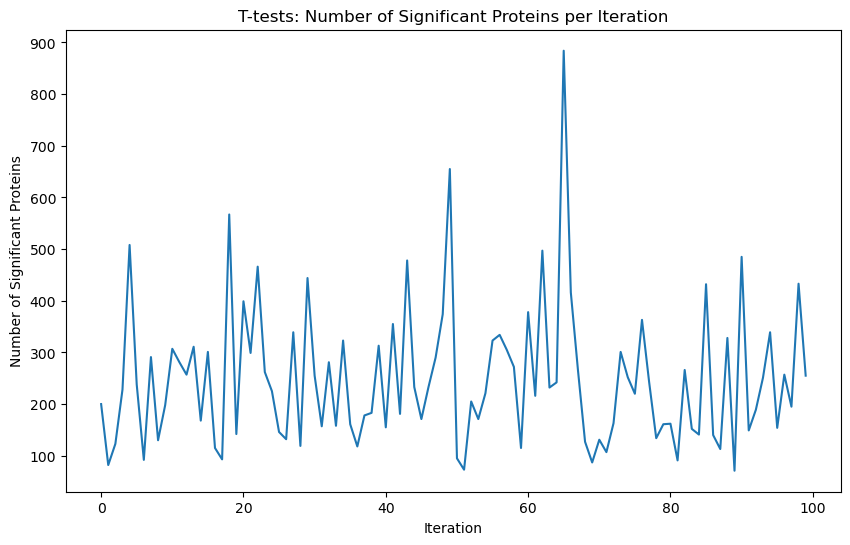

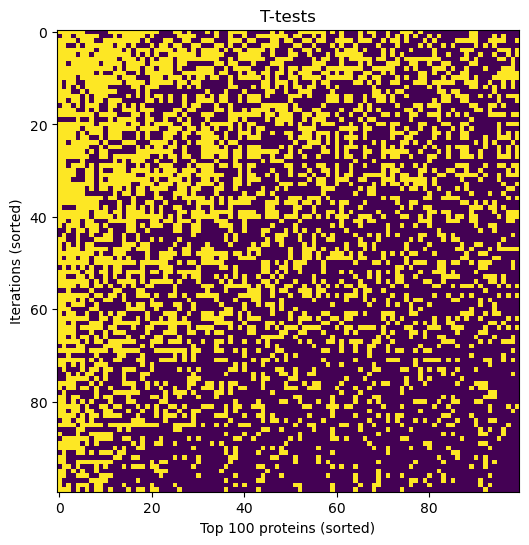

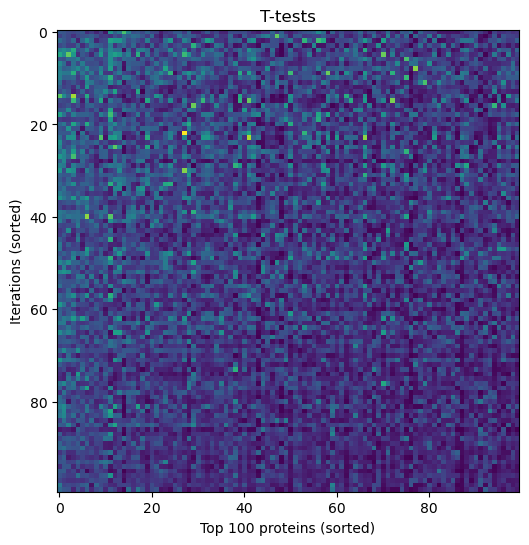

In [33]:
p_thres = 0.01
selection_matrix_tt = np.where(p_vals_matrix_tt < p_thres, 1, 0)

pi_proteins_tt = np.mean(selection_matrix_tt, axis=0)

n_selected_iteration_tt = np.sum(selection_matrix_tt, axis=1)

idx_sorted_tt = np.argsort(pi_proteins_tt)[::-1]
iter_sorted_tt = np.argsort(n_selected_iteration_tt)[::-1]

top_k = 100
plt.figure(figsize=(10, 6))
plt.plot(n_selected_iteration_tt)
plt.xlabel("Iteration")
plt.ylabel("Number of Significant Proteins")
plt.title("T-tests: Number of Significant Proteins per Iteration")
plt.show()

plt.figure(figsize=(10, 6))
plt.imshow(selection_matrix_tt[iter_sorted_tt][:, idx_sorted_tt[:top_k]])
plt.ylabel("Iterations (sorted)")
plt.xlabel(f"Top {top_k} proteins (sorted)")
plt.title("T-tests")
plt.show()

plt.figure(figsize=(10, 6))
plt.imshow(-np.log10(p_vals_matrix_tt[iter_sorted_tt][:, idx_sorted_tt[:top_k]]))
plt.ylabel("Iterations (sorted)")
plt.xlabel(f"Top {top_k} proteins (sorted)")
plt.title("T-tests")
plt.show()

c:\Users\Love\miniconda3\envs\proteomicsEnv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Love\miniconda3\envs\proteomicsEnv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Love\miniconda3\envs\proteomicsEnv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Love\miniconda3\envs\proteomicsEnv\Lib\site-packages\sklearn\cluster\_

Silhouette Score: 0.2170
Davies-Bouldin Index: 1.8094
Size of each cluster: [34 66]


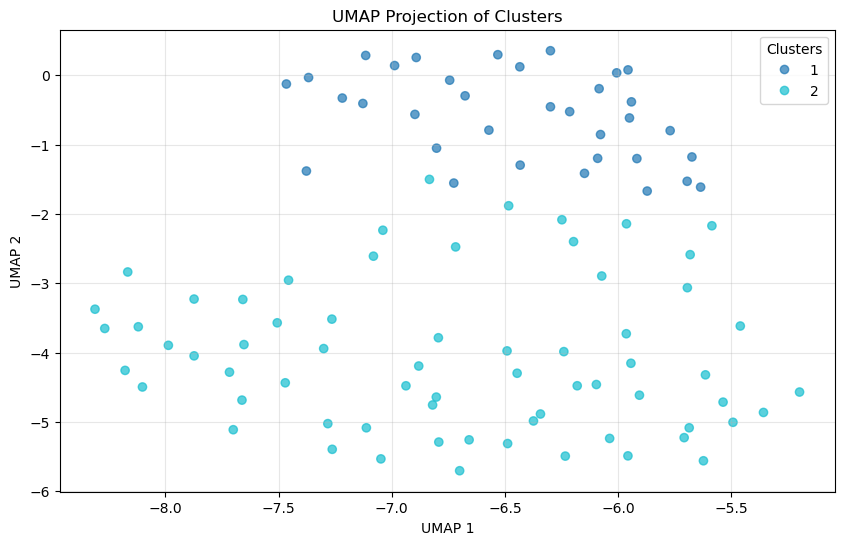

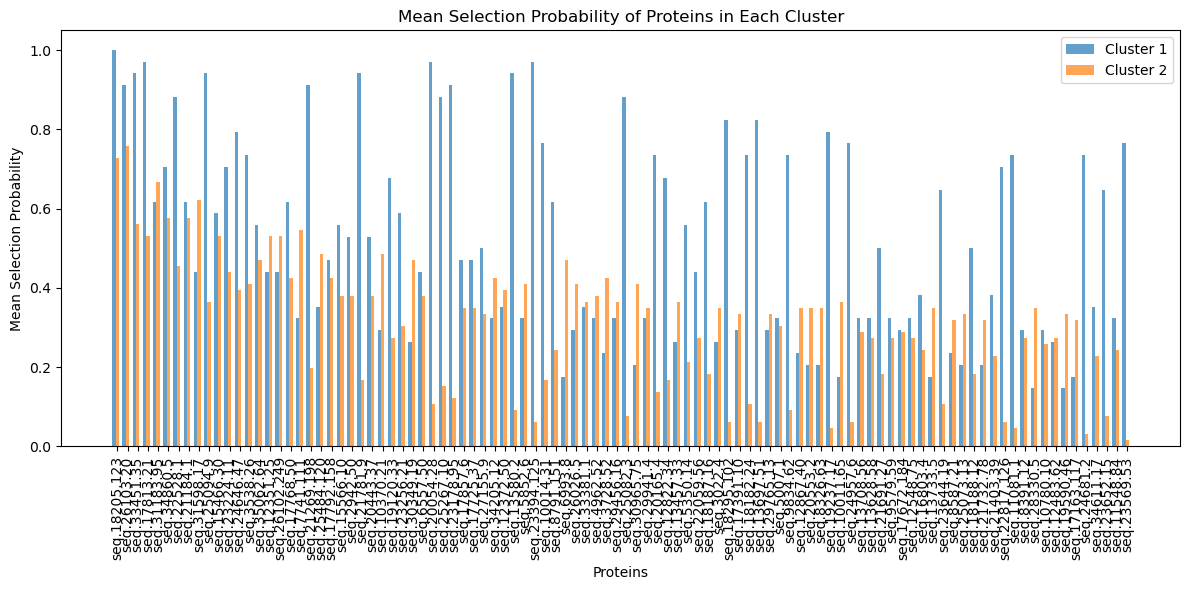

In [8]:
#top_k = 100
neg_log_pvals_tt = -np.log10(p_vals_matrix_tt[:, idx_sorted_tt[:top_k]])

# L2 normalization
#neg_log_pvals_tt = neg_log_pvals_tt / np.linalg.norm(neg_log_pvals_tt, axis=1, keepdims=True)

best_silhouette = -1
best_db_score = np.inf
best_k = None
for k in [2, 3, 4, 5, 6]:
    # Run KMeans clustering on p-values
    cluster_labels, _ = run_kmeans_clustering(neg_log_pvals_tt, n_clusters=k)
    silhouette_avg = silhouette_score(neg_log_pvals_tt, cluster_labels, metric="euclidean")
    davies_bouldin = davies_bouldin_score(neg_log_pvals_tt, cluster_labels)
    # Update best scores
    if silhouette_avg > best_silhouette:
        best_silhouette = silhouette_avg
        best_db_score = davies_bouldin
        best_cluster_labels = cluster_labels
        best_k = k

cluster_labels_tt, cluster_centras_tt = run_kmeans_clustering(neg_log_pvals_tt, n_clusters=best_k)
#cluster_labels_tt = run_dbscan_clustering(neg_log_pvals_tt, eps=10, min_samples=5, metric="euclidean")

silhouette_avg_tt = silhouette_score(neg_log_pvals_tt, cluster_labels_tt, metric="euclidean")
davies_bouldin_tt = davies_bouldin_score(neg_log_pvals_tt, cluster_labels_tt)

print(f"Silhouette Score: {silhouette_avg_tt:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_tt:.4f}")

print(f"Size of each cluster: {np.bincount(cluster_labels_tt)}")  # +1 to account for potential -1 in DBSCAN

plot_umap(neg_log_pvals_tt, cluster_labels_tt, metric="euclidean", random_state=None)
bar_plot_cluster_selection_probabilities(selection_matrix_tt[:, idx_sorted_tt[:top_k]], cluster_labels_tt, proteins=np.array(proteins)[idx_sorted_tt[:top_k]])

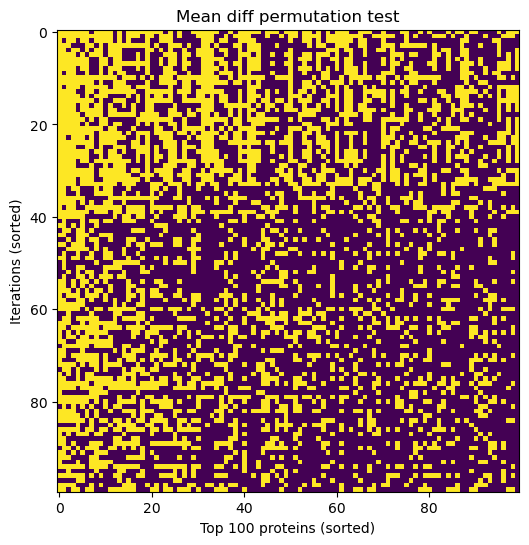

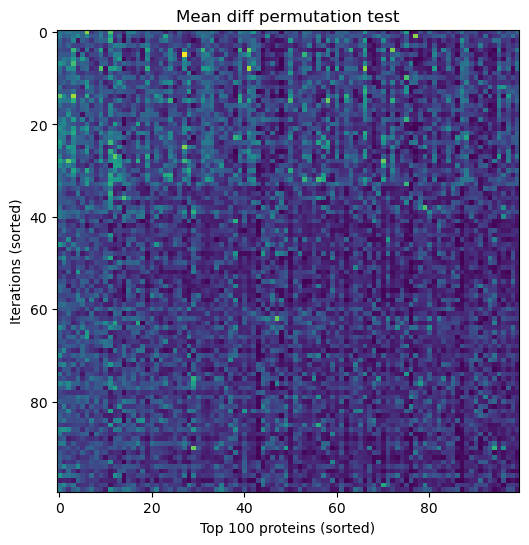

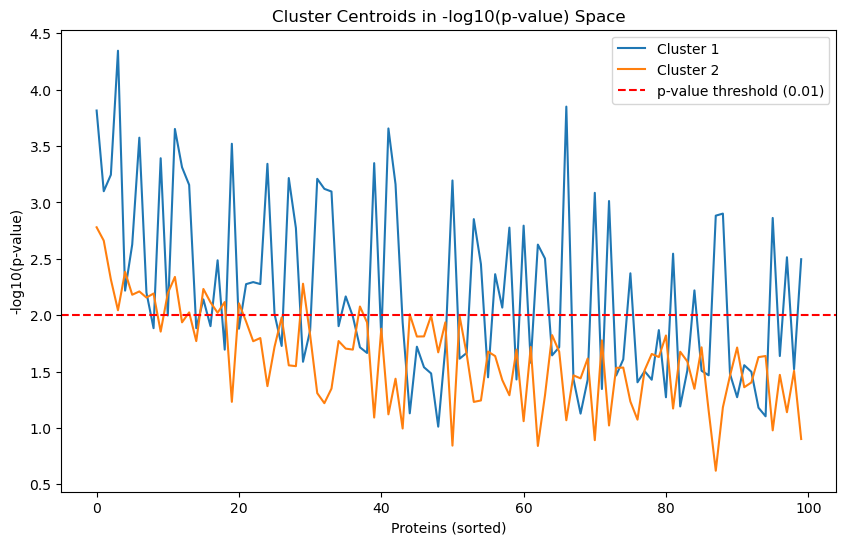

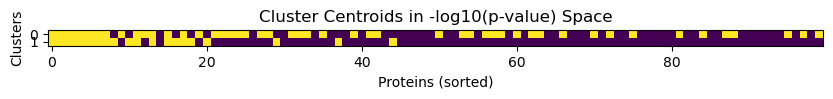

In [9]:
cluster_sorted_tt = np.argsort(cluster_labels_tt)

plt.figure(figsize=(10, 6))
plt.imshow(selection_matrix_tt[cluster_sorted_tt][:, idx_sorted_tt[:top_k]])
plt.ylabel("Iterations (sorted)")
plt.xlabel(f"Top {top_k} proteins (sorted)")
plt.title("Mean diff permutation test")
plt.show()

plt.figure(figsize=(10, 6))
plt.imshow(-np.log10(p_vals_matrix_tt[cluster_sorted_tt][:, idx_sorted_tt[:top_k]]))
plt.ylabel("Iterations (sorted)")
plt.xlabel(f"Top {top_k} proteins (sorted)")
plt.title("Mean diff permutation test")
plt.show()

# plot cluster centras
plt.figure(figsize=(10, 6))
for i in range(cluster_centras_tt.shape[0]):
    plt.plot(cluster_centras_tt[i], label=f"Cluster {i+1}")
plt.axhline(-np.log10(p_thres), color='red', linestyle='--', label=f'p-value threshold ({p_thres})')
plt.xlabel("Proteins (sorted)")
plt.ylabel("-log10(p-value)")
plt.title("Cluster Centroids in -log10(p-value) Space")
plt.legend()
plt.show()

cluster_centras_sig_tt = 10**(-cluster_centras_tt) < p_thres
plt.figure(figsize=(10, 6))
plt.imshow(cluster_centras_sig_tt)
plt.xlabel("Proteins (sorted)")
plt.ylabel("Clusters")
plt.title("Cluster Centroids in -log10(p-value) Space")
plt.show()

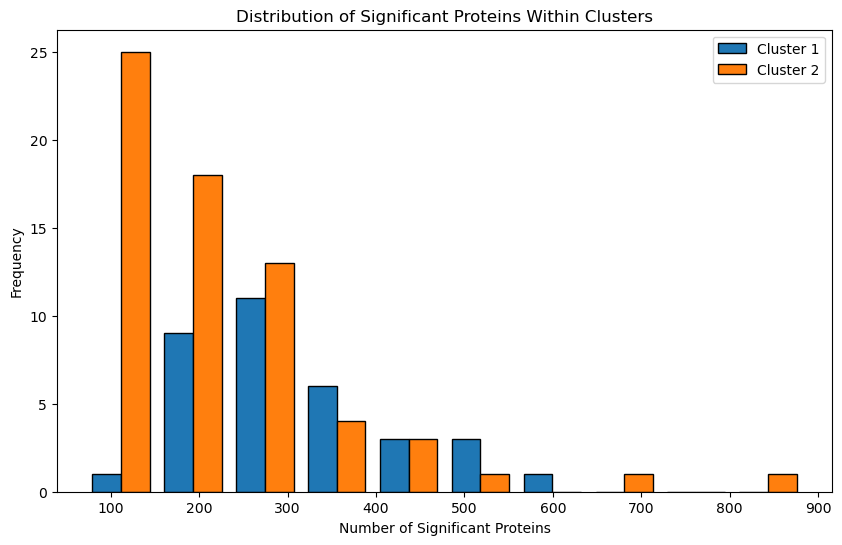

In [29]:
# Plot the distribution of the number of significant proteins within each cluster 
plt.figure(figsize=(10, 6))
#for i in np.unique(cluster_labels_tt):
#    plt.hist(n_selected_iteration_tt[cluster_labels_tt == i], bins=10, edgecolor='black', alpha=0.7, label=f'Cluster {i+1}')
plt.hist([n_selected_iteration_tt[cluster_labels_tt == i] for i in np.unique(cluster_labels_tt)], bins=10, edgecolor='black', label=[f'Cluster {i+1}' for i in np.unique(cluster_labels_tt)])
plt.xlabel('Number of Significant Proteins')
plt.ylabel('Frequency')
plt.title('Distribution of Significant Proteins Within Clusters')
plt.legend()
plt.show()

### Using permutation tests

In [11]:
n_samples, n_features = X_train.shape
n_iterations = 100

p_vals_matrix_pt = np.zeros((n_iterations, n_features))

for b in range(n_iterations):
    if (b+1) % 10 == 0:
        print(f"Iteration {b+1}/{n_iterations}")
    X_sub, _, y_sub, _ = train_test_split(X_train, y_train, test_size=0.6, random_state=b)

    mean_diff = np.abs(np.mean(X_sub[y_sub == 1], axis=0) - np.mean( X_sub[y_sub==0], axis=0))

    perms = 1000
    hits = np.zeros(len(mean_diff))
    rng = np.random.default_rng(42)
    for i in range(perms):
        y_perm = rng.permutation(y_sub)
        mean_diff_perm = np.abs(np.mean(X_sub[y_perm == 1], axis=0) - np.mean( X_sub[y_perm==0], axis=0))
    
        hits += np.where(mean_diff_perm >= mean_diff, 1, 0)
    
    p_vals = (hits + 1) / (perms + 1)

    # mutliple testing correction
    #_, p_vals_corrected, _, _ = multipletests(p_vals, method='fdr_bh')

    p_vals_matrix_pt[b] = p_vals

Iteration 10/100
Iteration 20/100
Iteration 30/100
Iteration 40/100
Iteration 50/100
Iteration 60/100
Iteration 70/100
Iteration 80/100
Iteration 90/100
Iteration 100/100


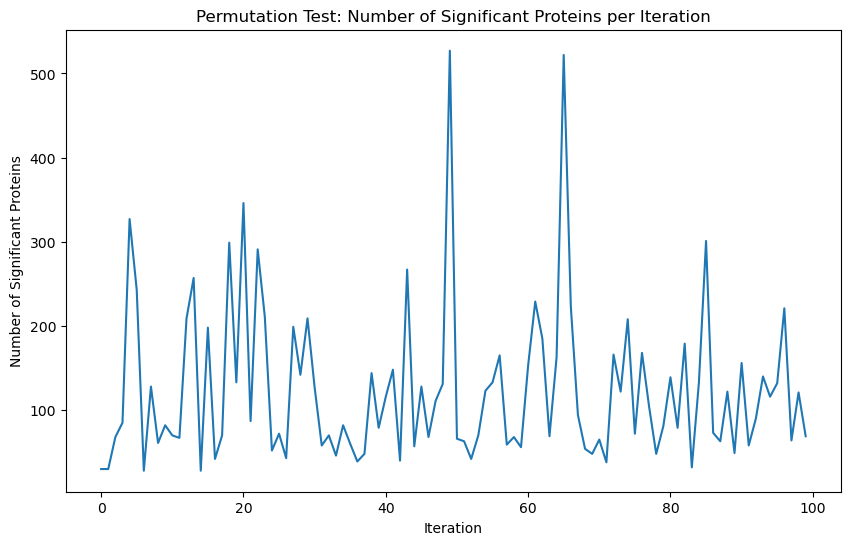

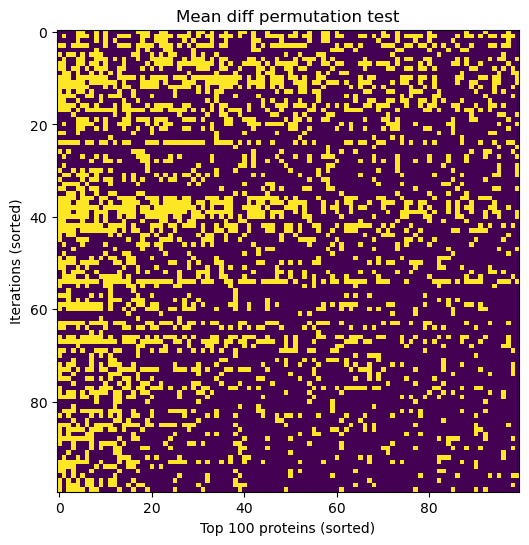

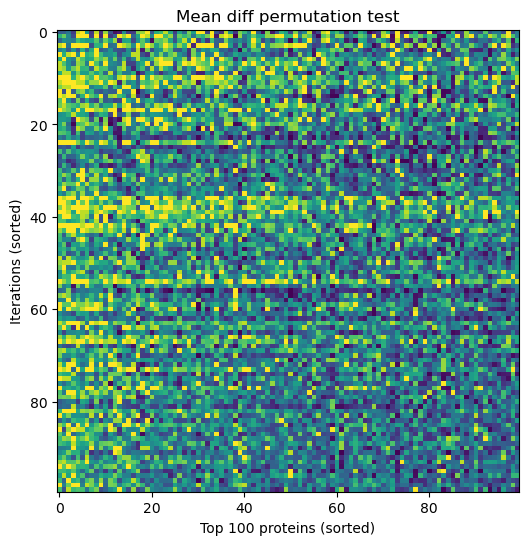

In [34]:
p_thres = 0.01
selection_matrix_pt = np.where(p_vals_matrix_pt < p_thres, 1, 0)

pi_proteins_pt = np.mean(selection_matrix_pt, axis=0)

n_selected_iteration_pt = np.sum(selection_matrix_pt, axis=1)

idx_sorted_pt = np.argsort(pi_proteins_pt)[::-1]
iter_sorted_pt = np.argsort(n_selected_iteration_tt)[::-1]

top_k = 100
plt.figure(figsize=(10, 6))
plt.plot(n_selected_iteration_pt)
plt.xlabel("Iteration")
plt.ylabel("Number of Significant Proteins")
plt.title("Permutation Test: Number of Significant Proteins per Iteration")
plt.show()

plt.figure(figsize=(10, 6))
plt.imshow(selection_matrix_pt[iter_sorted_pt][:, idx_sorted_pt[:top_k]])
plt.ylabel("Iterations (sorted)")
plt.xlabel(f"Top {top_k} proteins (sorted)")
plt.title("Mean diff permutation test")
plt.show()

plt.figure(figsize=(10, 6))
plt.imshow(-np.log10(p_vals_matrix_pt[iter_sorted_pt][:, idx_sorted_pt[:top_k]]))
plt.ylabel("Iterations (sorted)")
plt.xlabel(f"Top {top_k} proteins (sorted)")
plt.title("Mean diff permutation test")
plt.show()

c:\Users\Love\miniconda3\envs\proteomicsEnv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Love\miniconda3\envs\proteomicsEnv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Love\miniconda3\envs\proteomicsEnv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Love\miniconda3\envs\proteomicsEnv\Lib\site-packages\sklearn\cluster\_

Silhouette Score: 0.1407
Davies-Bouldin Index: 2.2287
Size of each cluster: [64 36]


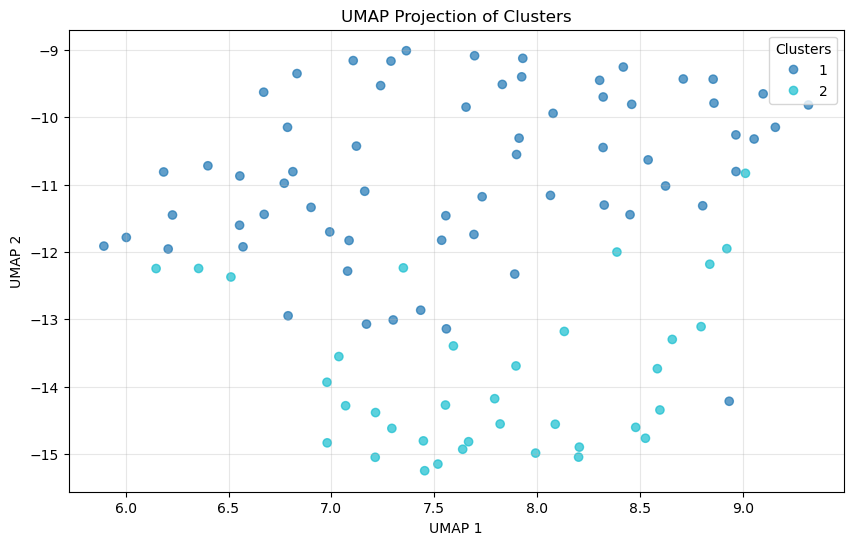

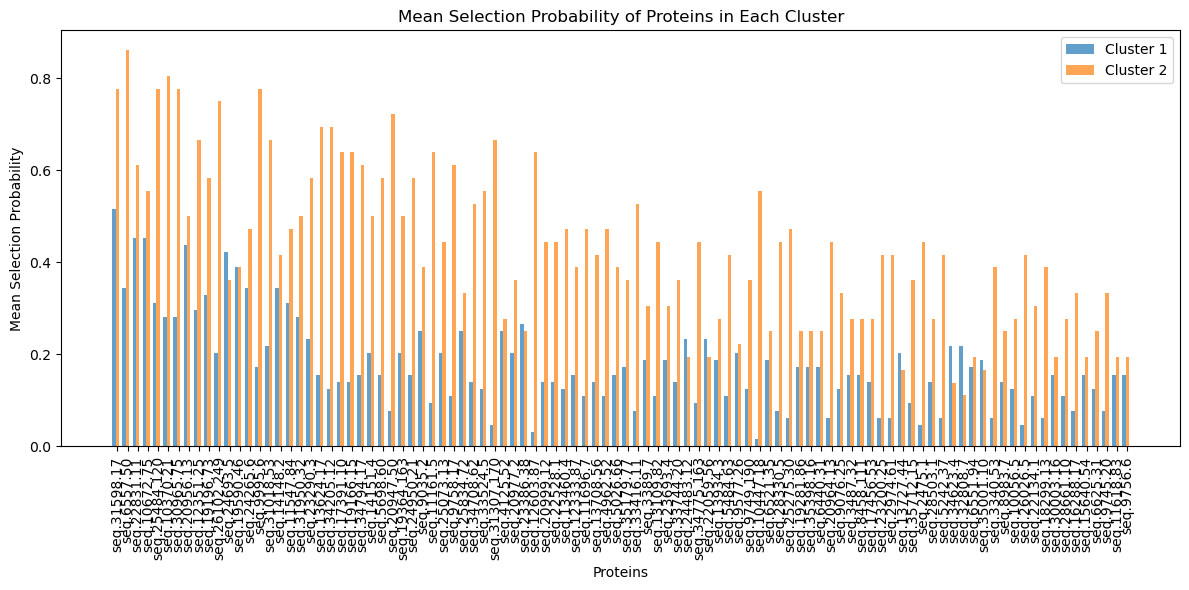

In [31]:
#top_k = 100
neg_log_pvals_pt = -np.log10(p_vals_matrix_pt[:, idx_sorted_pt[:top_k]])

best_silhouette = -1
best_db_score = np.inf
best_k = None
for k in [2, 3, 4, 5, 6]:
    # Run KMeans clustering on p-values
    cluster_labels, _ = run_kmeans_clustering(neg_log_pvals_pt, n_clusters=k)
    silhouette_avg = silhouette_score(neg_log_pvals_pt, cluster_labels, metric="euclidean")
    davies_bouldin = davies_bouldin_score(neg_log_pvals_pt, cluster_labels)
    # Update best scores
    if silhouette_avg > best_silhouette:
        best_silhouette = silhouette_avg
        best_db_score = davies_bouldin
        best_cluster_labels = cluster_labels
        best_k = k

cluster_labels_pt, cluster_centras_pt = run_kmeans_clustering(neg_log_pvals_pt, n_clusters=best_k)
#cluster_labels_pt = run_dbscan_clustering(neg_log_pvals_pt, eps=10, min_samples=5, metric="euclidean")

silhouette_avg_pt = silhouette_score(neg_log_pvals_pt, cluster_labels_pt, metric="euclidean")
davies_bouldin_pt = davies_bouldin_score(neg_log_pvals_pt, cluster_labels_pt)

print(f"Silhouette Score: {silhouette_avg_pt:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_pt:.4f}")

print(f"Size of each cluster: {np.bincount(cluster_labels_pt)}")  # +1 to account for potential -1 in DBSCAN

plot_umap(neg_log_pvals_pt, cluster_labels_pt, metric="euclidean", random_state=None)
bar_plot_cluster_selection_probabilities(selection_matrix_pt[:, idx_sorted_pt[:top_k]], cluster_labels_pt, proteins=np.array(proteins)[idx_sorted_pt[:top_k]])

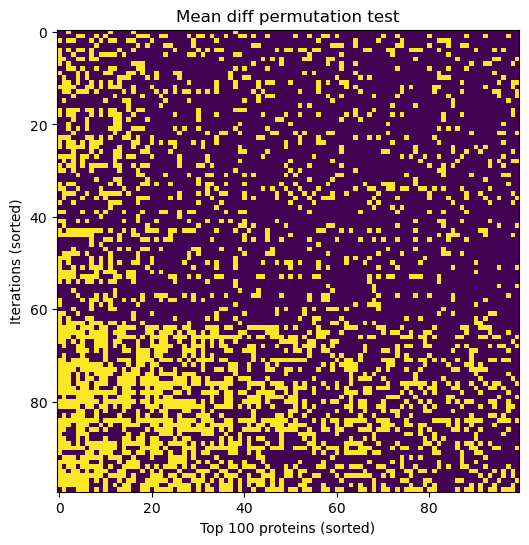

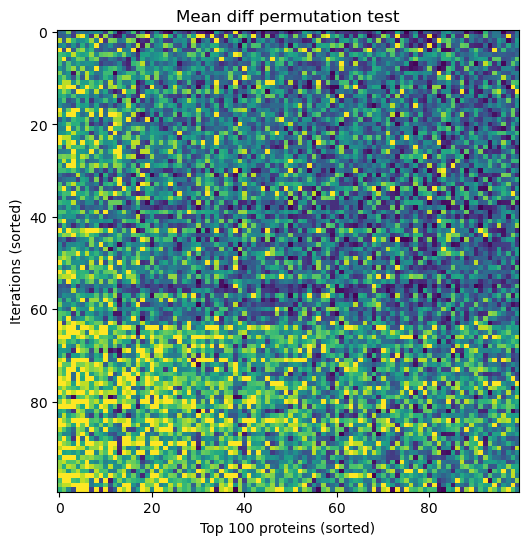

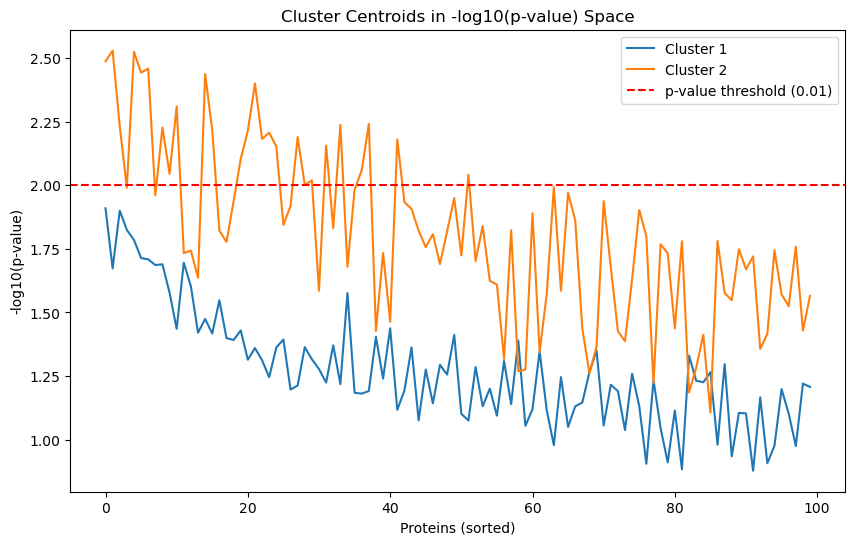

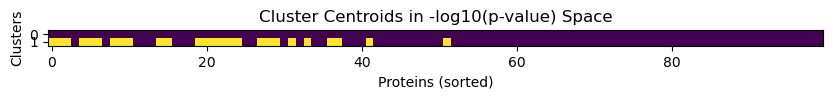

In [14]:
cluster_sorted_pt = np.argsort(cluster_labels_pt)

plt.figure(figsize=(10, 6))
plt.imshow(selection_matrix_pt[cluster_sorted_pt][:, idx_sorted_pt[:top_k]])
plt.ylabel("Iterations (sorted)")
plt.xlabel(f"Top {top_k} proteins (sorted)")
plt.title("Mean diff permutation test")
plt.show()

plt.figure(figsize=(10, 6))
plt.imshow(-np.log10(p_vals_matrix_pt[cluster_sorted_pt][:, idx_sorted_pt[:top_k]]))
plt.ylabel("Iterations (sorted)")
plt.xlabel(f"Top {top_k} proteins (sorted)")
plt.title("Mean diff permutation test")
plt.show()

# plot cluster centras
plt.figure(figsize=(10, 6))
for i in range(cluster_centras_pt.shape[0]):
    plt.plot(cluster_centras_pt[i], label=f"Cluster {i+1}")
plt.axhline(-np.log10(p_thres), color='red', linestyle='--', label=f'p-value threshold ({p_thres})')
plt.xlabel("Proteins (sorted)")
plt.ylabel("-log10(p-value)")
plt.title("Cluster Centroids in -log10(p-value) Space")
plt.legend()
plt.show()

cluster_centras_sig_pt = 10**(-cluster_centras_pt) < p_thres
plt.figure(figsize=(10, 6))
plt.imshow(cluster_centras_sig_pt)
plt.xlabel("Proteins (sorted)")
plt.ylabel("Clusters")
plt.title("Cluster Centroids in -log10(p-value) Space")
plt.show()

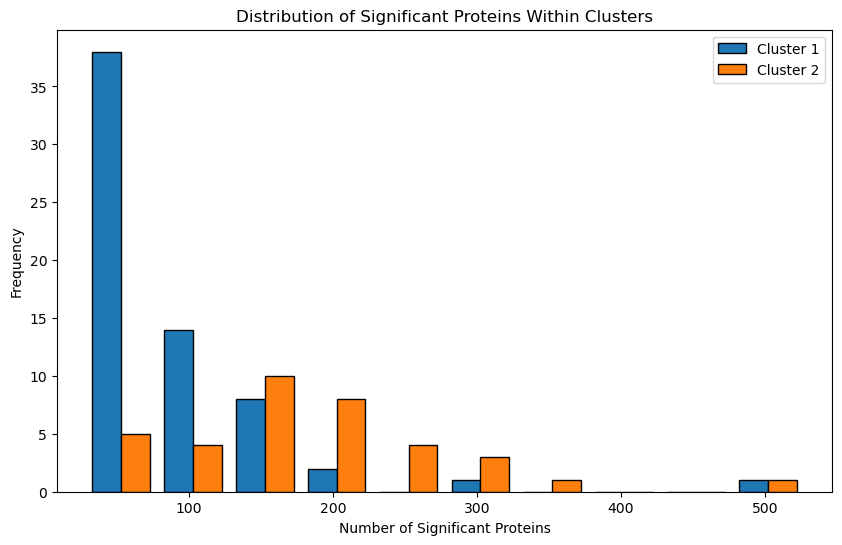

In [26]:
# Plot the distribution of the number of significant proteins within each cluster 
plt.figure(figsize=(10, 6))
#for i in np.unique(cluster_labels_tt):
#    plt.hist(n_selected_iteration_tt[cluster_labels_tt == i], bins=10, edgecolor='black', alpha=0.7, label=f'Cluster {i+1}')
plt.hist([n_selected_iteration_pt[cluster_labels_pt == i] for i in np.unique(cluster_labels_pt)], bins=10, edgecolor='black', label=[f'Cluster {i+1}' for i in np.unique(cluster_labels_pt)])
plt.xlabel('Number of Significant Proteins')
plt.ylabel('Frequency')
plt.title('Distribution of Significant Proteins Within Clusters')
plt.legend()
plt.show()

### Mann-Whitney U test

In [16]:
n_samples, n_features = X_train.shape
n_iterations = 100

p_vals_matrix_mw = np.zeros((n_iterations, n_features))

for b in range(n_iterations):
    if (b+1) % 10 == 0:
        print(f"Iteration {b+1}/{n_iterations}")
    X_sub, _, y_sub, _ = train_test_split(X_train, y_train, test_size=0.6, random_state=b)

    res = mannwhitneyu(X_sub[y_sub == 1], X_sub[y_sub == 0], axis=0, alternative="two-sided")
    p_vals = res.pvalue

    # mutliple testing correction
    #_, p_vals_corrected, _, _ = multipletests(p_vals, method='fdr_bh')

    p_vals_matrix_mw[b] = p_vals

Iteration 10/100
Iteration 20/100
Iteration 30/100
Iteration 40/100
Iteration 50/100
Iteration 60/100
Iteration 70/100
Iteration 80/100
Iteration 90/100
Iteration 100/100


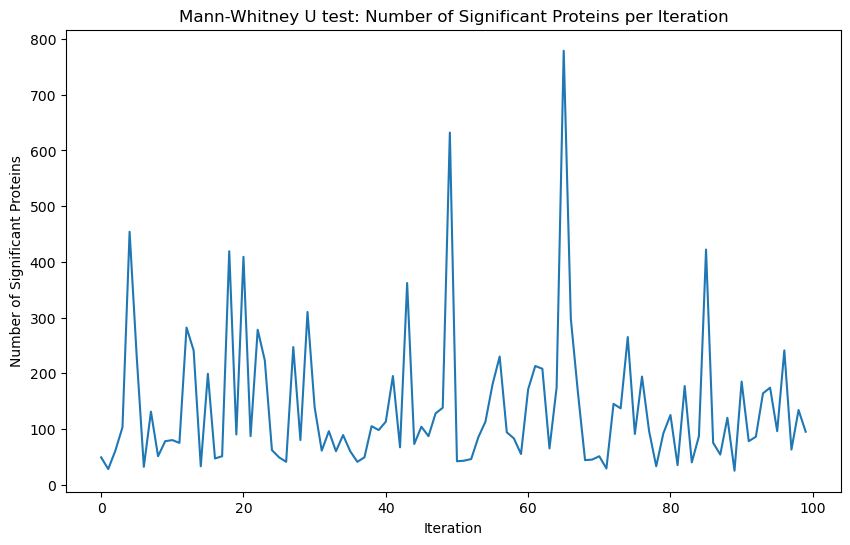

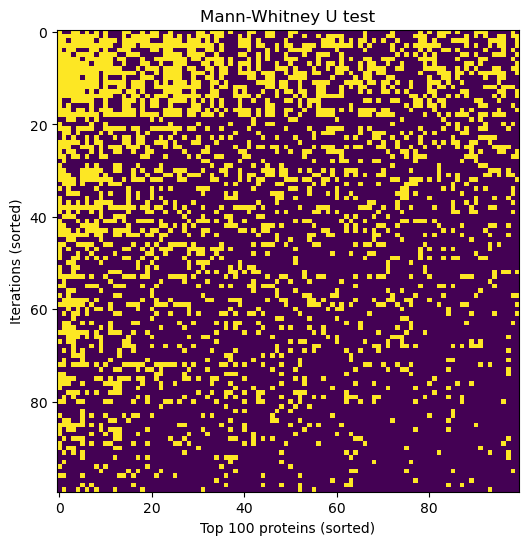

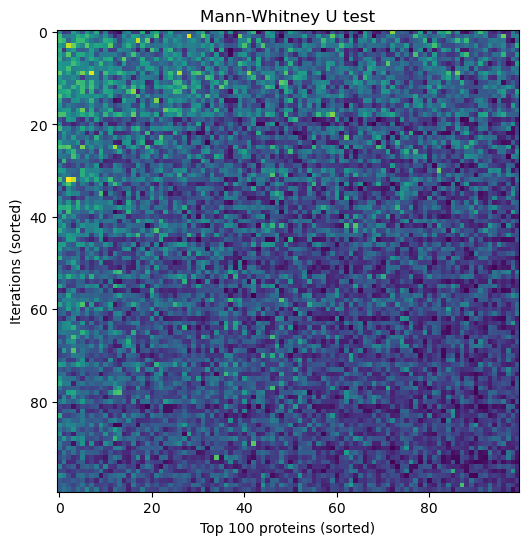

In [35]:
p_thres = 0.01
selection_matrix_mw = np.where(p_vals_matrix_mw < p_thres, 1, 0)

pi_proteins_mw = np.mean(selection_matrix_mw, axis=0)

n_selected_iteration_mw = np.sum(selection_matrix_mw, axis=1)

idx_sorted_mw = np.argsort(pi_proteins_mw)[::-1]
iter_sorted_mw = np.argsort(n_selected_iteration_mw)[::-1]

top_k = 100
plt.figure(figsize=(10, 6))
plt.plot(n_selected_iteration_mw)
plt.xlabel("Iteration")
plt.ylabel("Number of Significant Proteins")
plt.title("Mann-Whitney U test: Number of Significant Proteins per Iteration")
plt.show()

plt.figure(figsize=(10, 6))
plt.imshow(selection_matrix_mw[iter_sorted_mw][:, idx_sorted_mw[:top_k]])
plt.ylabel("Iterations (sorted)")
plt.xlabel(f"Top {top_k} proteins (sorted)")
plt.title("Mann-Whitney U test")
plt.show()

plt.figure(figsize=(10, 6))
plt.imshow(-np.log10(p_vals_matrix_mw[iter_sorted_mw][:, idx_sorted_mw[:top_k]]))
plt.ylabel("Iterations (sorted)")
plt.xlabel(f"Top {top_k} proteins (sorted)")
plt.title("Mann-Whitney U test")
plt.show()

c:\Users\Love\miniconda3\envs\proteomicsEnv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Love\miniconda3\envs\proteomicsEnv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Love\miniconda3\envs\proteomicsEnv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Love\miniconda3\envs\proteomicsEnv\Lib\site-packages\sklearn\cluster\_

Silhouette Score: 0.1747
Davies-Bouldin Index: 2.0971
Size of each cluster: [67 33]


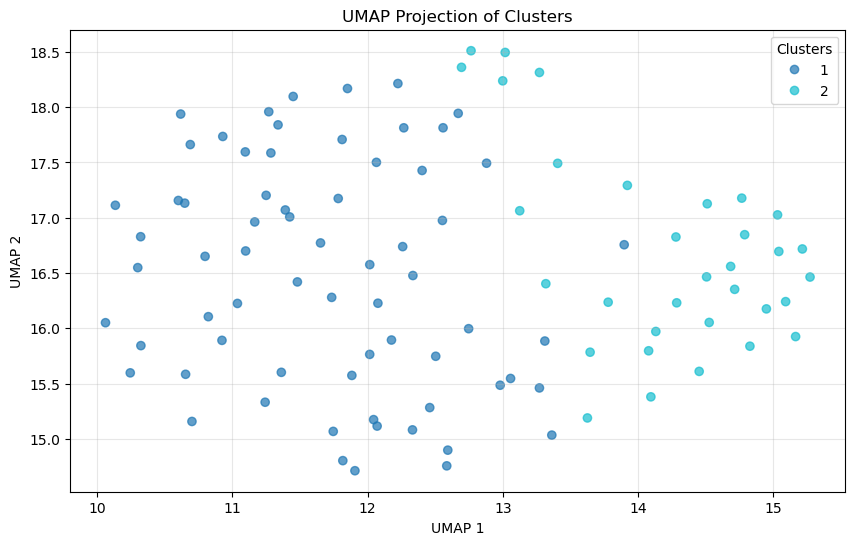

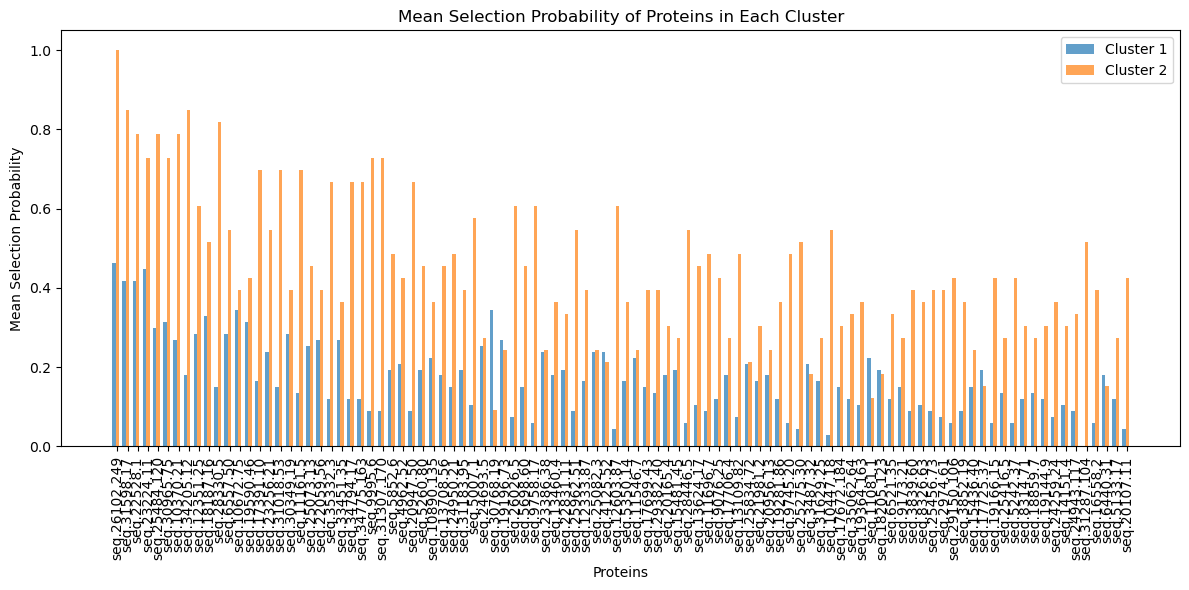

In [32]:
top_k = 100
neg_log_pvals_mw = -np.log10(p_vals_matrix_mw[:, idx_sorted_mw[:top_k]])

best_silhouette = -1
best_db_score = np.inf
best_k = None
for k in [2, 3, 4, 5, 6]:
    # Run KMeans clustering on p-values
    cluster_labels, _ = run_kmeans_clustering(neg_log_pvals_mw, n_clusters=k)
    silhouette_avg = silhouette_score(neg_log_pvals_mw, cluster_labels, metric="euclidean")
    davies_bouldin = davies_bouldin_score(neg_log_pvals_mw, cluster_labels)
    # Update best scores
    if silhouette_avg > best_silhouette:
        best_silhouette = silhouette_avg
        best_db_score = davies_bouldin
        best_cluster_labels = cluster_labels
        best_k = k

cluster_labels_mw, cluster_centras_mw = run_kmeans_clustering(neg_log_pvals_mw, n_clusters=best_k)
#cluster_labels_mw = run_dbscan_clustering(neg_log_pvals_mw, eps=10, min_samples=5, metric="euclidean")

silhouette_avg_mw = silhouette_score(neg_log_pvals_mw, cluster_labels_mw, metric="euclidean")
davies_bouldin_mw = davies_bouldin_score(neg_log_pvals_mw, cluster_labels_mw)

print(f"Silhouette Score: {silhouette_avg_mw:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_mw:.4f}")

print(f"Size of each cluster: {np.bincount(cluster_labels_mw)}")  # +1 to account for potential -1 in DBSCAN

plot_umap(neg_log_pvals_mw, cluster_labels_mw, metric="euclidean", random_state=None)
bar_plot_cluster_selection_probabilities(selection_matrix_mw[:, idx_sorted_mw[:top_k]], cluster_labels_mw, proteins=np.array(proteins)[idx_sorted_mw[:top_k]])

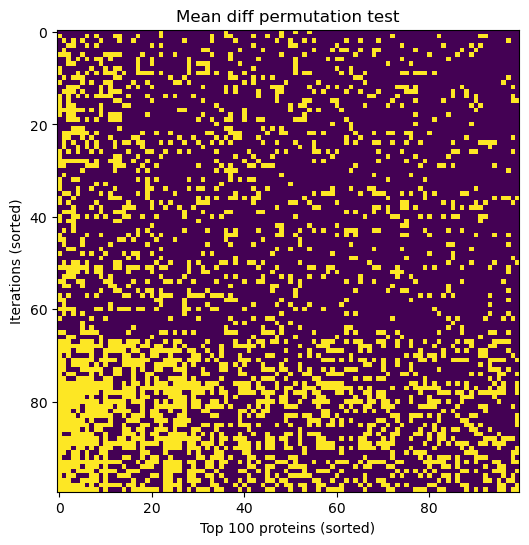

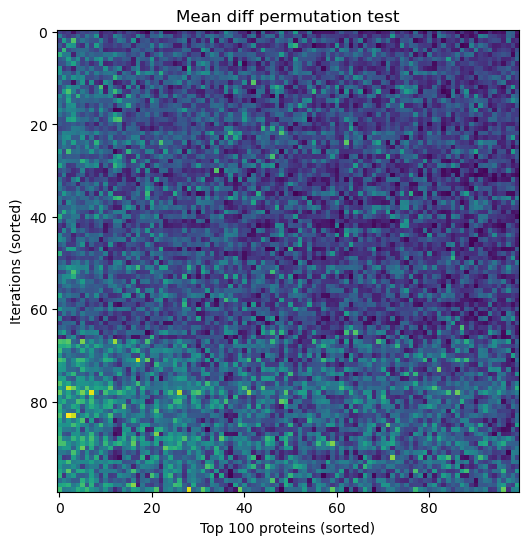

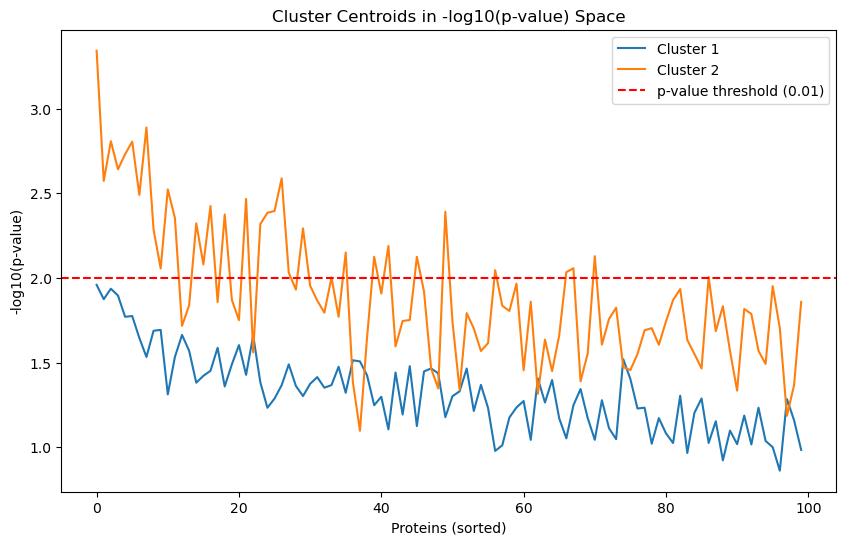

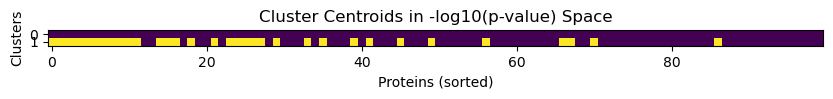

In [19]:
cluster_sorted_mw = np.argsort(cluster_labels_mw)

plt.figure(figsize=(10, 6))
plt.imshow(selection_matrix_mw[cluster_sorted_mw][:, idx_sorted_mw[:top_k]])
plt.ylabel("Iterations (sorted)")
plt.xlabel(f"Top {top_k} proteins (sorted)")
plt.title("Mean diff permutation test")
plt.show()

plt.figure(figsize=(10, 6))
plt.imshow(-np.log10(p_vals_matrix_mw[cluster_sorted_mw][:, idx_sorted_mw[:top_k]]))
plt.ylabel("Iterations (sorted)")
plt.xlabel(f"Top {top_k} proteins (sorted)")
plt.title("Mean diff permutation test")
plt.show()

# plot cluster centras
plt.figure(figsize=(10, 6))
for i in range(cluster_centras_mw.shape[0]):
    plt.plot(cluster_centras_mw[i], label=f"Cluster {i+1}")
plt.axhline(-np.log10(p_thres), color='red', linestyle='--', label=f'p-value threshold ({p_thres})')
plt.xlabel("Proteins (sorted)")
plt.ylabel("-log10(p-value)")
plt.title("Cluster Centroids in -log10(p-value) Space")
plt.legend()
plt.show()

cluster_centras_sig_mw = 10**(-cluster_centras_mw) < p_thres
plt.figure(figsize=(10, 6))
plt.imshow(cluster_centras_sig_mw)
plt.xlabel("Proteins (sorted)")
plt.ylabel("Clusters")
plt.title("Cluster Centroids in -log10(p-value) Space")
plt.show()

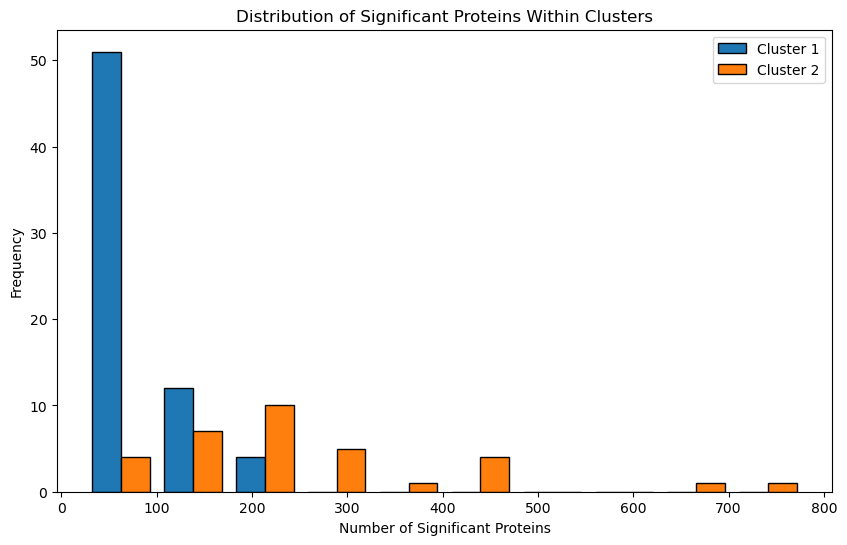

In [30]:
# Plot the distribution of the number of significant proteins within each cluster 
plt.figure(figsize=(10, 6))
#for i in np.unique(cluster_labels_tt):
#    plt.hist(n_selected_iteration_tt[cluster_labels_tt == i], bins=10, edgecolor='black', alpha=0.7, label=f'Cluster {i+1}')
plt.hist([n_selected_iteration_mw[cluster_labels_mw == i] for i in np.unique(cluster_labels_mw)], bins=10, edgecolor='black', label=[f'Cluster {i+1}' for i in np.unique(cluster_labels_mw)])
plt.xlabel('Number of Significant Proteins')
plt.ylabel('Frequency')
plt.title('Distribution of Significant Proteins Within Clusters')
plt.legend()
plt.show()

### Comparison

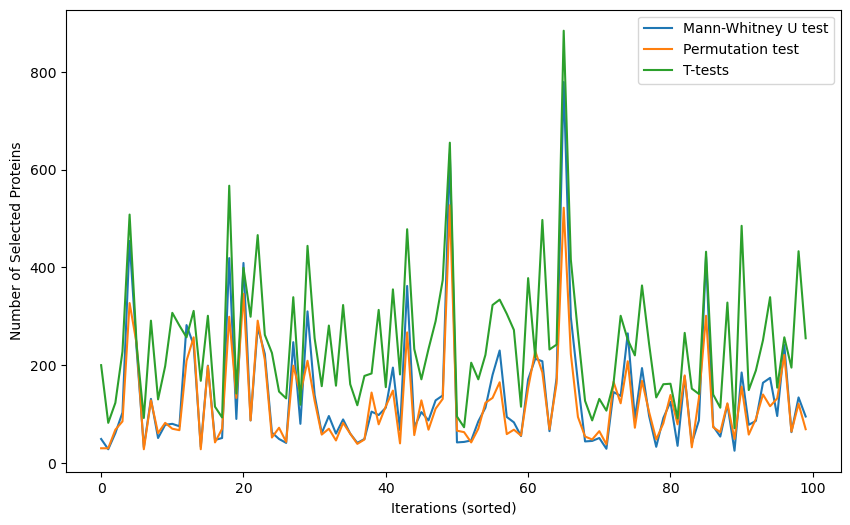

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(n_selected_iteration_mw, label="Mann-Whitney U test")
plt.plot(n_selected_iteration_pt, label="Permutation test")
plt.plot(n_selected_iteration_tt, label="T-tests")
plt.xlabel("Iterations (sorted)")
plt.ylabel("Number of Selected Proteins")
plt.title("")
plt.legend()
plt.show()

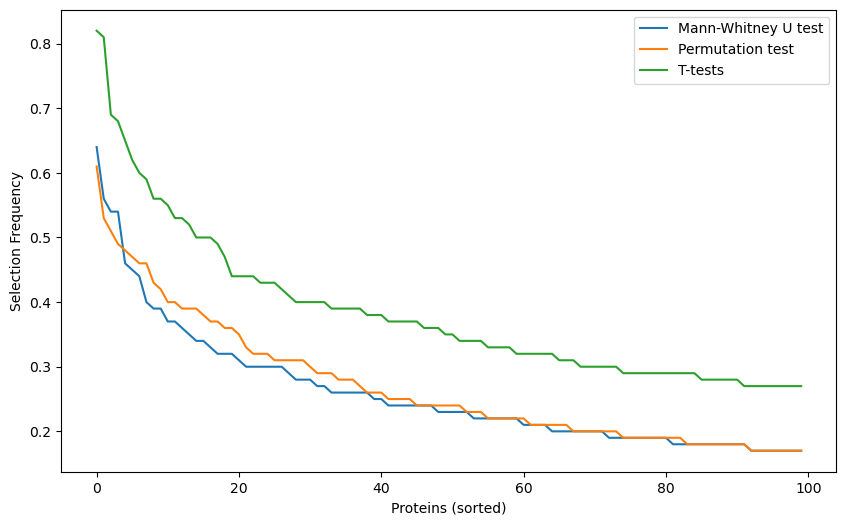

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(pi_proteins_mw[idx_sorted_mw[:top_k]], label="Mann-Whitney U test")
plt.plot(pi_proteins_pt[idx_sorted_pt[:top_k]], label="Permutation test")
plt.plot(pi_proteins_tt[idx_sorted_tt[:top_k]], label="T-tests")
plt.xlabel("Proteins (sorted)")
plt.ylabel("Selection Frequency")
plt.title("")
plt.legend()
plt.show()

### One t-test on full training set

In [79]:
def run_ttest(X, y, p_threshold=0.05, proteins=None):
    """Run t-tests for each protein and return the indices of selected proteins."""
    _, p_vals = stats.ttest_ind(
        X[y == 1], 
        X[y == 0], 
        axis=0, 
        equal_var=False, 
        nan_policy='omit'
    )

    # Adjust for multiple testing
    reject, adj_p_vals, _, _ = multipletests(p_vals, alpha=p_threshold, method='fdr_bh')
    #reject = p_vals < p_threshold
    #adj_p_vals = None

    if proteins is not None:
        sig_proteins = [prot for prot, is_sig in zip(proteins, reject) if is_sig]
        return reject, adj_p_vals, sig_proteins

    return reject, adj_p_vals

sig_proteins_idx, _, sig_proteins = run_ttest(X_train, y_train, p_threshold=0.05, proteins=proteins)
probeid = [seq_to_probeid(prot) for prot in sig_proteins]
protein_sig_df = pd.DataFrame({
    "PROBEID": probeid,
    "protein": sig_proteins
})
protein_sig_df = protein_sig_df.merge(annot_df, on="PROBEID", how="left")
#protein_sig_df.head()
for row in protein_sig_df.itertuples():
    print(f"{row.SYMBOL}")

print(sig_proteins_idx.sum())

STAT1
COL9A1
HAO1
ALDH5A1
BPHL
MAGEA6
BLOC1S2
PHF11
RGN
AGXT
ACSS2
ARID3C
DUT
SDHAF2
IL27
MAFF
HSF4
PABPC1
nan
DDC
RTF1
21


# Classifier

In [82]:
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    roc_auc_score,
)
from sklearn.metrics import roc_curve

### Baseline

In [83]:
lr_model_baseline = LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced")

lr_model_baseline.fit(X_train[:, sig_proteins_idx], y_train)

rf_model_baseline = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=5, class_weight="balanced")
rf_model_baseline.fit(X_train[:, sig_proteins_idx], y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Test AUC: 0.6165
Test Accuracy: 0.7805
Test F1 Score: 0.3077
Confusion Matrix:
[[60  9]
 [ 9  4]]
Classification Report:
              precision    recall  f1-score   support

       False       0.87      0.87      0.87        69
        True       0.31      0.31      0.31        13

    accuracy                           0.78        82
   macro avg       0.59      0.59      0.59        82
weighted avg       0.78      0.78      0.78        82



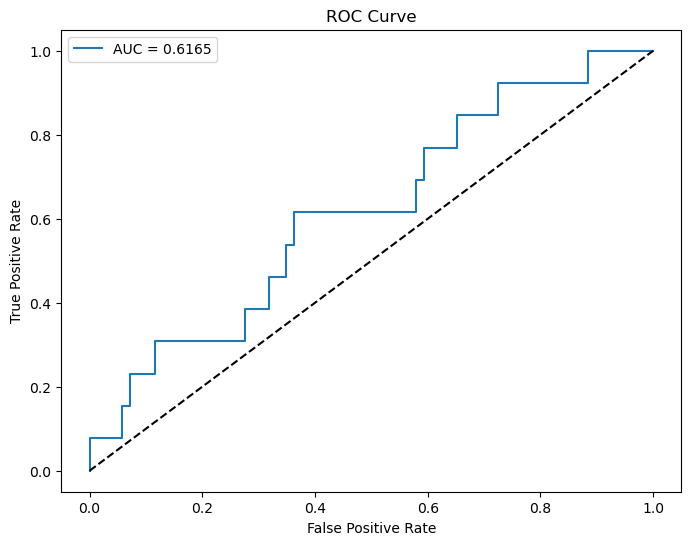

In [84]:
# Evaluate on test set
proba = rf_model_baseline.predict_proba(X_test[:, sig_proteins_idx])[:, 1]
pred = rf_model_baseline.predict(X_test[:, sig_proteins_idx])

auc = roc_auc_score(y_test, proba)
acc = accuracy_score(y_test, pred)
f1 = f1_score(y_test, pred)

print(f"Test AUC: {auc:.4f}")
print(f"Test Accuracy: {acc:.4f}")
print(f"Test F1 Score: {f1:.4f}")

print("Confusion Matrix:")
print(confusion_matrix(y_test, pred))

print("Classification Report:")
print(classification_report(y_test, pred))

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()


### T-tests

In [45]:
idx_sorted_tt[:100][cluster_centras_sig_tt[1]]

array([2247, 4712, 7359, 2183, 6368, 8066, 3592, 3049, 6559, 1722, 3764,
       8351,  661, 4711, 2148, 9729, 4542, 5968, 7726, 9549])

In [51]:
protein_sets_tt = [idx_sorted_tt[:cluster_centras_sig_tt.shape[1]][cluster_centras_sig_tt[i]] for i in range(cluster_centras_sig_tt.shape[0])]

In [60]:
# union of protein sets
protein_set_tt = set()
for i in range(cluster_centras_sig_tt.shape[0]):
    protein_set_tt.update(protein_sets_tt[i])

# convert to np array
protein_set_tt = np.array(list(protein_set_tt))

In [85]:
lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced")
lr_model.fit(X_train[:, protein_set_tt], y_train)

rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=5, class_weight="balanced")
rf_model.fit(X_train[:, protein_set_tt], y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Test AUC: 0.5998
Test Accuracy: 0.8171
Test F1 Score: 0.2857
Confusion Matrix:
[[64  5]
 [10  3]]
Classification Report:
              precision    recall  f1-score   support

       False       0.86      0.93      0.90        69
        True       0.38      0.23      0.29        13

    accuracy                           0.82        82
   macro avg       0.62      0.58      0.59        82
weighted avg       0.79      0.82      0.80        82



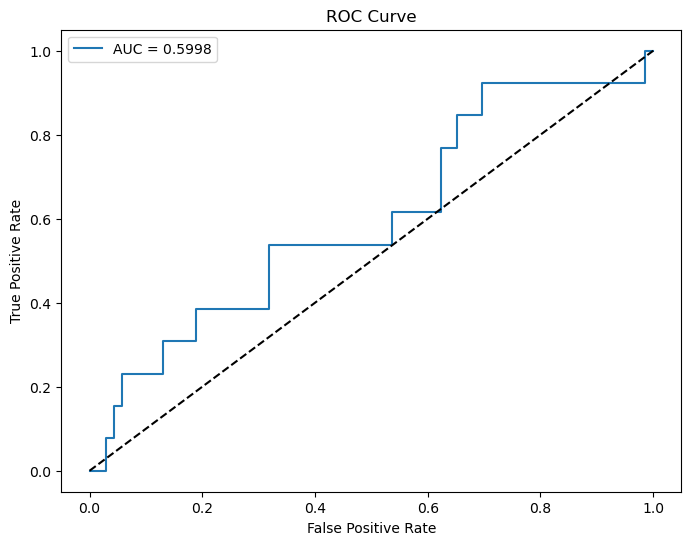

In [86]:
# Evaluate on test set
proba = rf_model.predict_proba(X_test[:, protein_set_tt])[:, 1]
pred = rf_model.predict(X_test[:, protein_set_tt])

auc = roc_auc_score(y_test, proba)
acc = accuracy_score(y_test, pred)
f1 = f1_score(y_test, pred)

print(f"Test AUC: {auc:.4f}")
print(f"Test Accuracy: {acc:.4f}")
print(f"Test F1 Score: {f1:.4f}")

print("Confusion Matrix:")
print(confusion_matrix(y_test, pred))

print("Classification Report:")
print(classification_report(y_test, pred))

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()


# Proteins sets

In [87]:
# Check overlap of selected proteins between baseline t-test and cluster-based selection
overlap_tt = set(np.where(sig_proteins_idx)[0]) & set(protein_set_tt)
print(f"Number of proteins in baseline t-test selection: {sig_proteins_idx.sum()}")
print(f"Number of proteins in cluster-based selection: {len(protein_set_tt)}")
print(f"Number of overlapping proteins: {len(overlap_tt)}")

Number of proteins in baseline t-test selection: 21
Number of proteins in cluster-based selection: 57
Number of overlapping proteins: 21


In [97]:
probeid = [seq_to_probeid(proteins[idx]) for idx in protein_set_tt]
protein_sig_df_cluster = pd.DataFrame({
    "PROBEID": probeid,
    "protein": np.array(proteins)[protein_set_tt]
})
protein_sig_df_cluster = protein_sig_df_cluster.merge(annot_df, on="PROBEID", how="left")
#protein_sig_df_cluster.head()
for row in protein_sig_df_cluster.itertuples():
    print(f"{row.SYMBOL}")
    

RTF1
nan
ACY3
BPHL
PHF11
SNAI2
EPHX2
STAT1
PSPH
GPC6
DDC
GPD1
TEN1
MAFF
WASL
HNMT
ACO1
DAO
ADH1B
TKFC
PABPC1
ACSS2
PCK1
RGN
GPD1
PIPOX
GAS2
ASPA
GRHPR
GATM
COL9A1
ARID3C
HSF4
TLDC2
LRFN3
USH1C
MAGEA6
NT5E
SEC14L2
TRIM9
DPYS
APBB1
IL27
HAO1
DUT
SDHAF2
BLOC1S2
UAP1
ESPN
CNN1
HSPA12A
DDT
ALDH5A1
CYCS
AGXT
STARD10
PALMD
